<a href="https://colab.research.google.com/github/Kunal-7O7/Machine-Learning-Algorithms/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Titanic Survival Prediction

In [ ]:
# First we need to import the basic libraries for data analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importing the dataset form Seaborn

df=sns.load_dataset("titanic")

In [ ]:
# Basic Eda
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [ ]:
df.shape

(891, 15)

In [ ]:
# Checking how many Duplicate values we have

df.duplicated().sum()

np.int64(107)

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: >

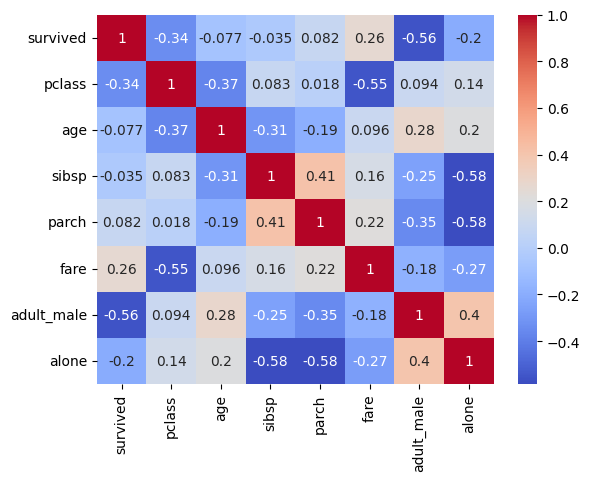

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

In [ ]:
# Checking the missing values

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
# To fitting a model we need to convert all the relevent columns into numerical value only after filling the missing values

df["age"]=df["age"].fillna(df["age"].median())
df["embark_town"]=df["embark_town"].fillna(df["embark_town"].mode()[0])

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
# if we closely seeing the data than we found that some columns are sharing the same information so we will directly remove them
# from the our data like who and adult_male can be drived from sex columnn,pclass and class are only sharing the class type of pessenger
# alive if directly showing the taget variable, so we prefer to remove the columns so the algo will not confus.

df.drop(["embarked","class","who","adult_male","deck","alive"],axis=1,inplace=True)


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,Southampton,True
3,1,1,female,35.0,1,0,53.1000,Southampton,False
4,0,3,male,35.0,0,0,8.0500,Southampton,True


In [ ]:
# Now to to fit a model we nee to convert all the categorical columns into numerical values

df["sex"]=df["sex"].map({"female":0,
                         "male":1})

In [ ]:
# To convert the embark_town we will use one hot encoding as they do not follow any order else we will use label endocer

df=pd.get_dummies(df,columns=["embark_town"],drop_first=True,dtype=int)

In [ ]:
# Now converting alone column into int type

df["alone"]=df["alone"].astype(int)

In [ ]:
# Now our data is ready for building a model
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,embark_town_Queenstown,embark_town_Southampton
0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,0,38.0,1,0,71.2833,0,0,0
2,1,3,0,26.0,0,0,7.9250,1,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,1
4,0,3,1,35.0,0,0,8.0500,1,0,1


In [ ]:
# importing all the important library for model

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [ ]:
x=df.drop("survived",axis=1)
y=df["survived"]

In [ ]:
x

,pclass,sex,age,sibsp,parch,fare,alone,embark_town_Queenstown,embark_town_Southampton
0,3,1,22.0,1,0,7.2500,0,0,1
1,1,0,38.0,1,0,71.2833,0,0,0
2,3,0,26.0,0,0,7.9250,1,0,1
3,1,0,35.0,1,0,53.1000,0,0,1
4,3,1,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,1,0,1
887,1,0,19.0,0,0,30.0000,1,0,1
888,3,0,28.0,1,2,23.4500,0,0,1
889,1,1,26.0,0,0,30.0000,1,0,0


In [ ]:
# Now for Builind our LogisticRegression Model we Need to divide the data into train & test

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20)

#cheking the shape for all the splited data

print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)


(712, 9) (179, 9)
(712,) (179,)


In [ ]:
# initialize the model
model=LogisticRegression(max_iter=1000)

model.fit(x_train,y_train)




LogisticRegression(max_iter=1000)

In [ ]:
# Now Predicting the y_pred value by fitting the data on test value

y_pred=model.predict(x_test)

In [ ]:
print(y_pred)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


In [ ]:
print(model.predict_proba(x_test).shape)

(179, 2)


In [ ]:
pd.Series(y_pred).value_counts()

,count
0,109
1,70


In [ ]:
unique,counts=np.unique(y_pred,return_counts=True)
print(unique,counts)

np.bincount(y_pred)

[0 1] [109  70]


array([109,  70])

In [ ]:
# Now We are chekcing our model score

cm=confusion_matrix(y_test,y_pred)
print(cm)



[[89 16]
 [20 54]]


In [ ]:
tn,fp,fn,tp=cm.ravel()

print("True_Negative",tn)
print("False_Negative",fn)
print("False_Positive",fp)
print("True_Positive",tp)

True_Negative 89
False_Negative 20
False_Positive 16
True_Positive 54


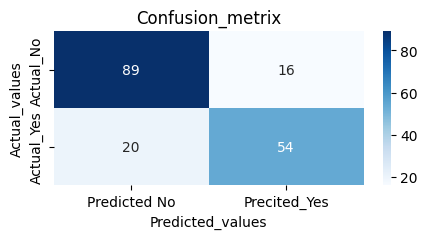

In [ ]:
# Now try to visualize it

plt.figure(figsize=(5,2))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Predicted No","Precited_Yes"],
            yticklabels=["Actual_No","Actual_Yes"])

plt.xlabel("Predicted_values")
plt.ylabel("Actual_values")
plt.title("Confusion_metrix")
plt.show()

In [ ]:
#Showing the model accuracy by precision,recall,F1-score.

print("Accuracy_Score",accuracy_score(y_test,y_pred))
print("classification_metrix",classification_report(y_test,y_pred))


Accuracy_Score 0.7988826815642458
classification_metrix               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
# We can also show separate score by skitlearn model

from sklearn.metrics import precision_score,recall_score,f1_score
print("precision",precision_score(y_test,y_pred)*100)
print("recall",recall_score(y_test,y_pred)*100)
print("F1_Score",f1_score(y_test,y_pred)*100)

precision 77.14285714285715
recall 72.97297297297297
F1_Score 75.0


In [ ]:
# To Check the how many actual negative our model is also identify

specificity=tn/(tn+fp)
print("Specificity",specificity*100)

Specificity 84.76190476190476


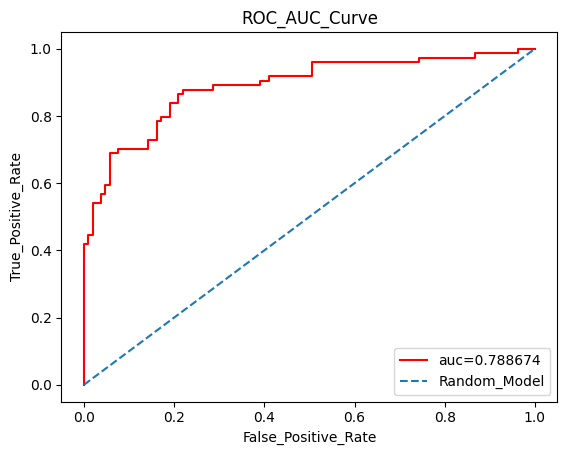

In [ ]:
# Now to check the ROC-AUC curve

from sklearn.metrics import roc_curve,roc_auc_score

y_prob = model.predict_proba(x_test)[:,1]

fpr,tpr,thersholds=roc_curve(y_test,y_prob)

plt.plot(fpr,tpr,color="red",label=f"auc={auc:3f}")
plt.plot([0,1],[0,1],linestyle="--",label="Random_Model")
plt.title("ROC_AUC_Curve")
plt.xlabel("False_Positive_Rate")
plt.ylabel("True_Positive_Rate")
plt.legend()
plt.show()




In [ ]:
# Now Checking the AUC_Score

auc=roc_auc_score(y_test,y_pred)
print("AUC_score",round(auc*100,2),"%")

AUC_score 78.87 %


ROC-AUC Score = 0.789

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate at different classification thresholds.

The model achieved an AUC score of 0.789, which indicates that it has a good ability to distinguish between passengers who survived and those who did not. Since the ROC curve lies well above the diagonal reference line (random classifier), the model performs significantly better than random guessing.